In [1]:
import kagglehub
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

file = '/content/possum.csv'

df = pd.read_csv(file)
df = df.iloc[:,1:]

In [2]:
df.head()

,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [3]:
df.tail()

,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
99,7,other,m,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,7,other,m,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,7,other,f,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,7,other,m,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0
103,7,other,f,3.0,93.6,59.9,89.0,40.0,67.6,46.0,14.8,28.5,33.5


In [4]:
df.info(())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   site      104 non-null    int64  
 1   Pop       104 non-null    object 
 2   sex       104 non-null    object 
 3   age       102 non-null    float64
 4   hdlngth   104 non-null    float64
 5   skullw    104 non-null    float64
 6   totlngth  104 non-null    float64
 7   taill     104 non-null    float64
 8   footlgth  103 non-null    float64
 9   earconch  104 non-null    float64
 10  eye       104 non-null    float64
 11  chest     104 non-null    float64
 12  belly     104 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 10.7+ KB


In [5]:
df.isnull().sum()

,0
site,0
Pop,0
sex,0
age,2
hdlngth,0
skullw,0
totlngth,0
taill,0
footlgth,1
earconch,0


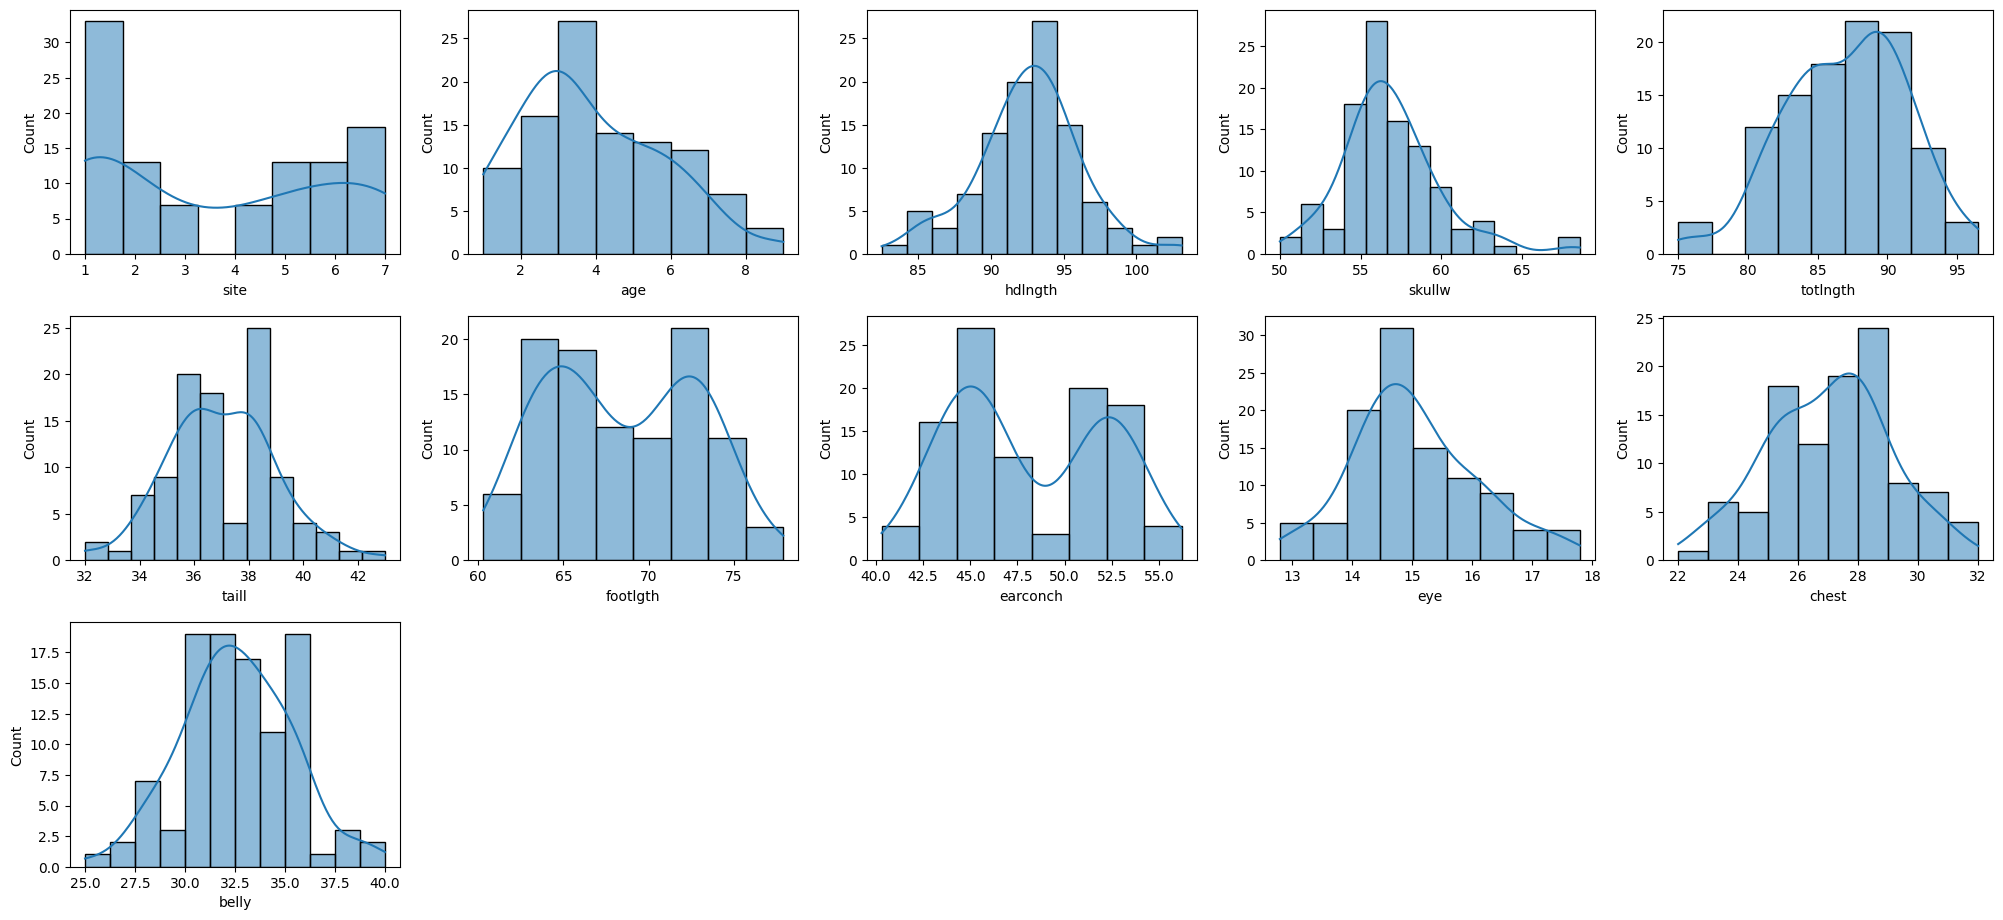

In [6]:
r,c = 5,5

plt.figure(figsize=(20, 15))

for i,o in zip(df.select_dtypes(include = 'number').columns, range(1,12)):

    plt.subplot(r,c,o)
    sns.histplot(data = df, x = i, kde = True)

plt.tight_layout()
plt.show()

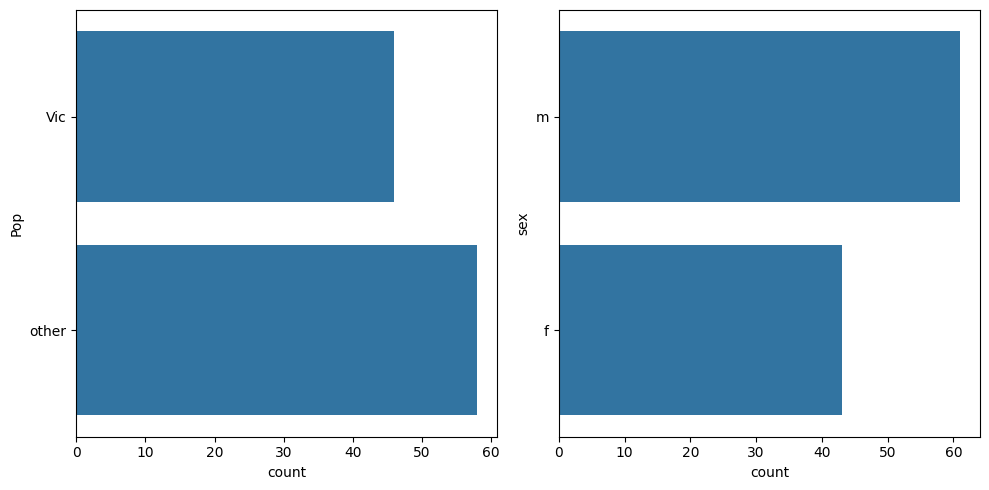

In [7]:
r,c = 1,2

plt.figure(figsize=(10, 5))

for i,o in zip(df.select_dtypes(exclude = 'number').columns, range(1,3)):

    plt.subplot(r,c,o)
    sns.countplot(data = df, y = i)

plt.tight_layout()
plt.show()

<Axes: >

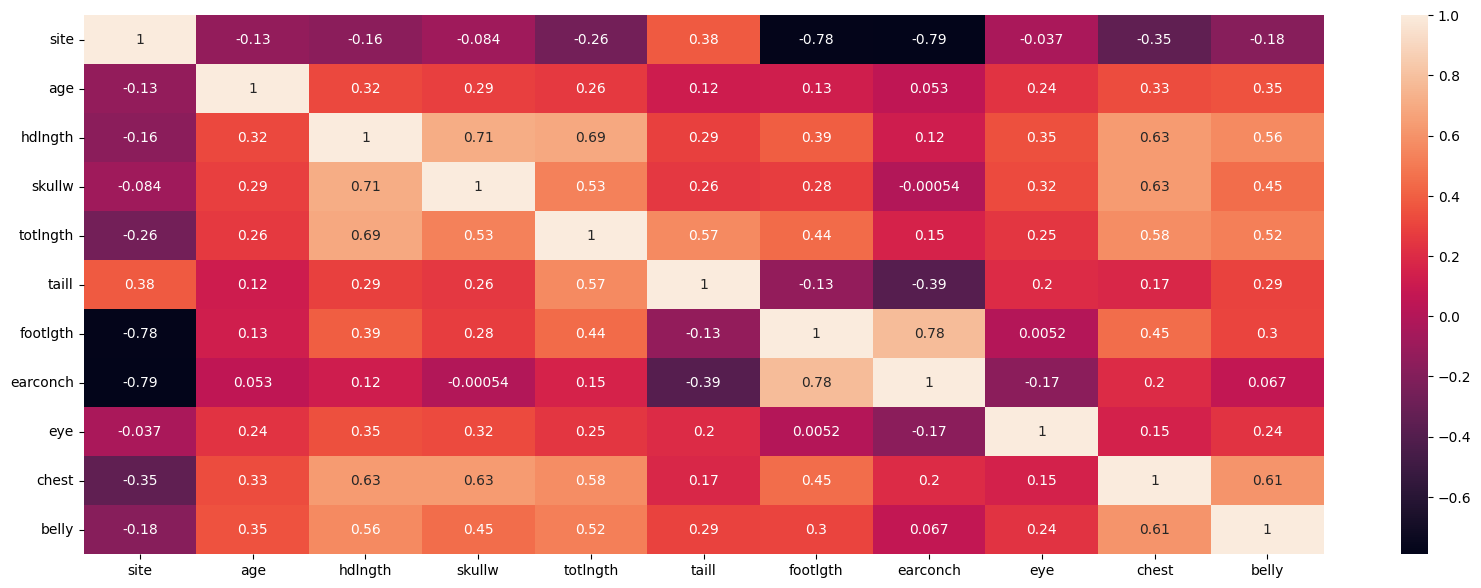

In [8]:
plt.figure(figsize = (20, 7))
sns.heatmap(df.select_dtypes(include = 'number').corr(), annot = True)

In [9]:
df = df.dropna(subset=['age'])

X = df.drop('age', axis = 1)
y = df['age']

from sklearn.model_selection import train_test_split, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 69)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

num = X_train.select_dtypes(include = 'number').columns
cat = X_train.select_dtypes(exclude = 'number').columns

imputer = SimpleImputer(missing_values = np.nan, strategy = 'mean')

num_pipe = make_pipeline(
    SimpleImputer(missing_values = np.nan, strategy = 'mean'),
    StandardScaler()
)

processor = make_column_transformer(
    (num_pipe, num),
    (OneHotEncoder(drop = 'first', sparse_output = False), cat)
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

pipe = make_pipeline(
    processor,
    RandomForestRegressor()
)

pipe.fit(X_train, y_train)
print(pipe.score(X_train, y_train), pipe.score(X_test, y_test))

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

0.8830682152061855 0.14955997409326427
MAE : 1.6974193548387095
RMSE: 2.0246242184184333
R²  : 0.14955997409326427


In [10]:
import joblib

joblib.dump(pipe, 'model.pkl')

['model.pkl']